# Example on classification setting

Suppose we want to predict if a recession will occur within the next 24 months
- Sample: 1982:M1 -- 2026:M1
- Explanatory variables:
    - Unemployment rate: $\Delta unrate_{t, t-12}$
    - Term spread: 10 years - 3 months US T-Bills spread
- Train sample: until 2016:M5
- Test sample: 2016:M6 -- 2026:M1
- Dependent variable:

$$
y_t \;=\; 1\left\{\max_{h=1,\ldots,H} R_{t+h} = 1\right\}; \quad H=24
$$

The dependent variable is equal to 1 if a recession will occur in the next 24 months

## 0. Required packages

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 1. Download and prepare data

We retrieve the data from FRED and match the monthly frequency

In [5]:
def fred_series(series_id: str) -> pd.Series:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, parse_dates=["observation_date"])
    df = df.set_index("observation_date")
    s = pd.to_numeric(df[series_id].replace(".", np.nan), errors="coerce")
    s.name = series_id
    return s


standardize = False
max_k = 200
usrec = fred_series("USREC")  # monthly recession indicator (0/1)
unrate = fred_series("UNRATE")  # monthly unemployment rate (%)
t10y3m = fred_series("T10Y3M")  # daily (often), 10y-3m term spread (%)

# Convert term spread to monthly (mean is stable; last is also ok)
t10y3m_m = t10y3m.resample("ME").mean()

# Align everything to monthly index
df = pd.concat([usrec.resample("ME").last(), unrate.resample("ME").last(), t10y3m_m], axis=1).dropna()

# -----------------------------
# Features and target
# -----------------------------
df["spread"] = df["T10Y3M"]  # term spread
df["d_unrate_12"] = df["UNRATE"] - df["UNRATE"].shift(12)  # 12-month change in unemployment

# Target: recession occurs at any point in the next 12 months (excluding current month)
future_rec = df["USREC"].shift(-1)
df["y"] = (future_rec[::-1].rolling(24, min_periods=24).max()[::-1] > 0).astype(int)

data = df[["spread", "d_unrate_12", "y"]].dropna()

X = data[["spread", "d_unrate_12"]].to_numpy()
y = data["y"].to_numpy()


split = int(0.8 * len(data))
X_tr, y_tr = X[:split], y[:split]
X_te, y_te = X[split:], y[split:]

X_tr_s = X_tr
X_te_s = X_te

## 3. K-Nearest Neighbors

We use KNN with different K degrees, from 1 to 200.

1. Choose a test observation $x_0$
2. Identify the $K$ training data points closest to $x_0$ ($\mathcal{N}_0$)
3. Estimate the conditional probability for class $j$:

   $$
   \Pr(Y = j \mid X = x_0) = \frac{1}{K} \sum_{i \in \mathcal{N}_0} 1(y_i = j)
   $$

4. Classify $x_0$ to the class $j$ with the largest probability

We use a Leave-One-Out (LOO) logic to compute the train and test error rates.

The key problem they solve is this: with KNN at k=1, every training point's nearest neighbor is itself, so it always predicts correctly, giving a fake 0% training error. LOO fixes this by:

1. Fitting NearestNeighbors with k+1 neighbors
2. Then dropping the first neighbor (which is always the point itself, at distance 0)
3. Predicting using only the remaining k genuine neighbors


In [7]:
k_list = list(range(1, max_k, 5))  # odd ks


def loo_knn_train_error(X, y, k, weights="distance"):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)  # +1 to include self
    dist, ind = nn.kneighbors(X)

    dist = dist[:, 1:]  # drop self
    ind = ind[:, 1:]
    y_nb = y[ind]

    if weights == "uniform":
        p1 = y_nb.mean(axis=1)
    else:
        w = 1.0 / np.maximum(dist, 1e-12)
        p1 = (w * y_nb).sum(axis=1) / w.sum(axis=1)

    yhat = (p1 >= 0.5).astype(int)
    return 1 - accuracy_score(y, yhat)


# use it in your loop:
train_err, test_err = [], []
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn.fit(X_tr_s, y_tr)
    train_err.append(loo_knn_train_error(X_tr_s, y_tr, k, weights="distance"))
    test_err.append(1 - accuracy_score(y_te, knn.predict(X_te_s)))

best_k = k_list[int(np.argmin(test_err))]

# -----------------------------
# Decision boundary plots for a few k
# -----------------------------
ks_show = [1, best_k, max_k]

# Build a grid in *standardized* feature space for plotting decision regions
x1 = X_tr_s[:, 0]
x2 = X_tr_s[:, 1]
pad = 0.6
x1_grid = np.linspace(x1.min() - pad, x1.max() + pad, 300)
x2_grid = np.linspace(x2.min() - pad, x2.max() + pad, 300)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
grid = np.c_[xx1.ravel(), xx2.ravel()]

def loo_knn_train_acc(X, y, k, weights="distance"):
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)  # +1 includes self
    dist, ind = nn.kneighbors(X)

    dist = dist[:, 1:]   # drop self
    ind  = ind[:, 1:]
    y_nb = y[ind]

    if weights == "uniform":
        p1 = y_nb.mean(axis=1)
    else:
        w = 1.0 / np.maximum(dist, 1e-12)
        p1 = (w * y_nb).sum(axis=1) / w.sum(axis=1)

    yhat = (p1 >= 0.5).astype(int)
    return (yhat == y).mean()


## 5. Plot

Best k on this split: 166
Baseline (always predict 'no recession in next 12m') test accuracy = 0.760


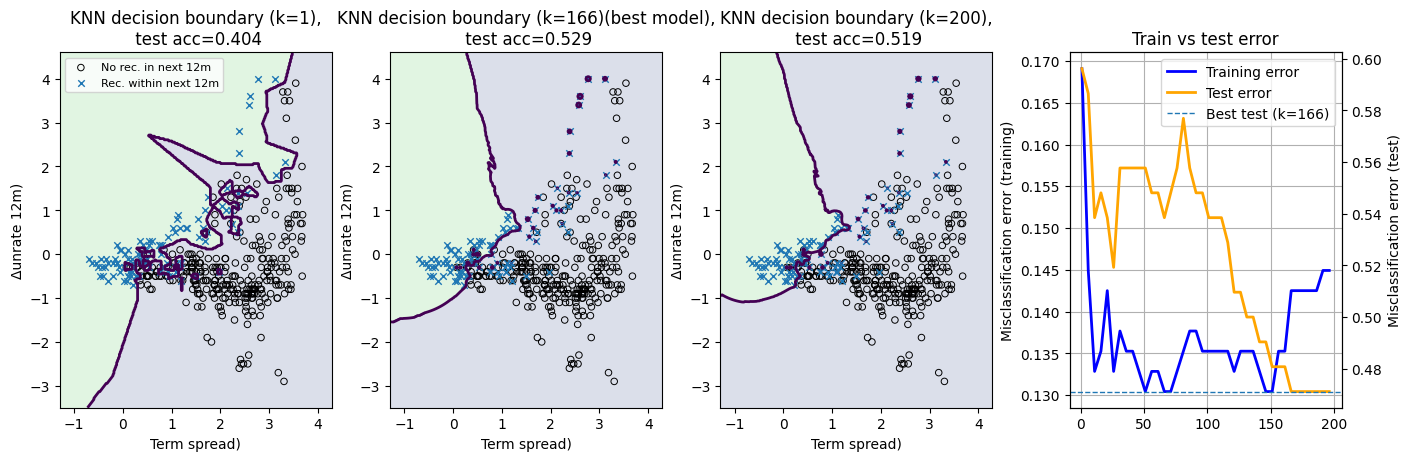

In [8]:

def plot_boundary(ax, k, best=False):
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn.fit(X_tr_s, y_tr)
    prob = knn.predict_proba(grid)[:, 1].reshape(xx1.shape)

    ax.contourf(xx1, xx2, (prob >= 0.5).astype(int), alpha=0.18, levels=[-0.5, 0.5, 1.5])
    ax.contour(xx1, xx2, prob, levels=[0.5], linewidths=2)  # decision boundary

    # training points
    ax.scatter(X_tr_s[y_tr == 0, 0], X_tr_s[y_tr == 0, 1], s=22, facecolors="none",
               edgecolors="black", linewidths=0.7, label="No rec. in next 12m")
    ax.scatter(X_tr_s[y_tr == 1, 0], X_tr_s[y_tr == 1, 1], s=22, marker="x",
               linewidths=1.0, label="Rec. within next 12m")

    tr_acc = loo_knn_train_acc(X_tr_s, y_tr, k, weights="distance")
    te_acc = accuracy_score(y_te, knn.predict(X_te_s), normalize=True)
    best_label = "(best model)" if best else ""
    ax.set_title(f"KNN decision boundary (k={k})" + best_label+f",\n test acc={te_acc:.3f}")
    ax.set_xlabel("Term spread)")
    ax.set_ylabel("Δunrate 12m)")


# -----------------------------
# Plot: boundaries + error curve
# -----------------------------
fig = plt.figure(figsize=(14, 4.5), constrained_layout=True)
gs = fig.add_gridspec(1, 4)

ax0 = fig.add_subplot(gs[0, 0])
plot_boundary(ax0, ks_show[0])
ax0.legend(frameon=True, fontsize=8, loc="upper left")

ax1 = fig.add_subplot(gs[0, 1])
plot_boundary(ax1, ks_show[1], best=True)

ax2 = fig.add_subplot(gs[0, 2])
plot_boundary(ax2, ks_show[2])
ax3 = fig.add_subplot(gs[0, 3])
flex = np.array(k_list, dtype=float)

l1, = ax3.plot(flex, train_err, linewidth=2, label="Training error", color="blue")
ax3.set_ylabel("Misclassification error (training)")
ax3.grid(True)

ax3_ = ax3.twinx()
l2, = ax3_.plot(flex, test_err, linewidth=2, label="Test error", color="orange")
l3 = ax3_.axhline(min(test_err), linestyle="--", linewidth=1,
                  label=f"Best test (k={best_k})")

ax3_.set_ylabel("Misclassification error (test)")
ax3_.set_title("Train vs test error")
ax3_.set_xlabel("In-Flexibility (k)")

# combined legend (both axes)
handles = [l1, l2, l3]
labels = [h.get_label() for h in handles]
ax3.legend(handles, labels, frameon=True)


print(f"Best k on this split: {best_k}")
print(f"Baseline (always predict 'no recession in next 12m') test accuracy = {(y_te == 0).mean():.3f}")
